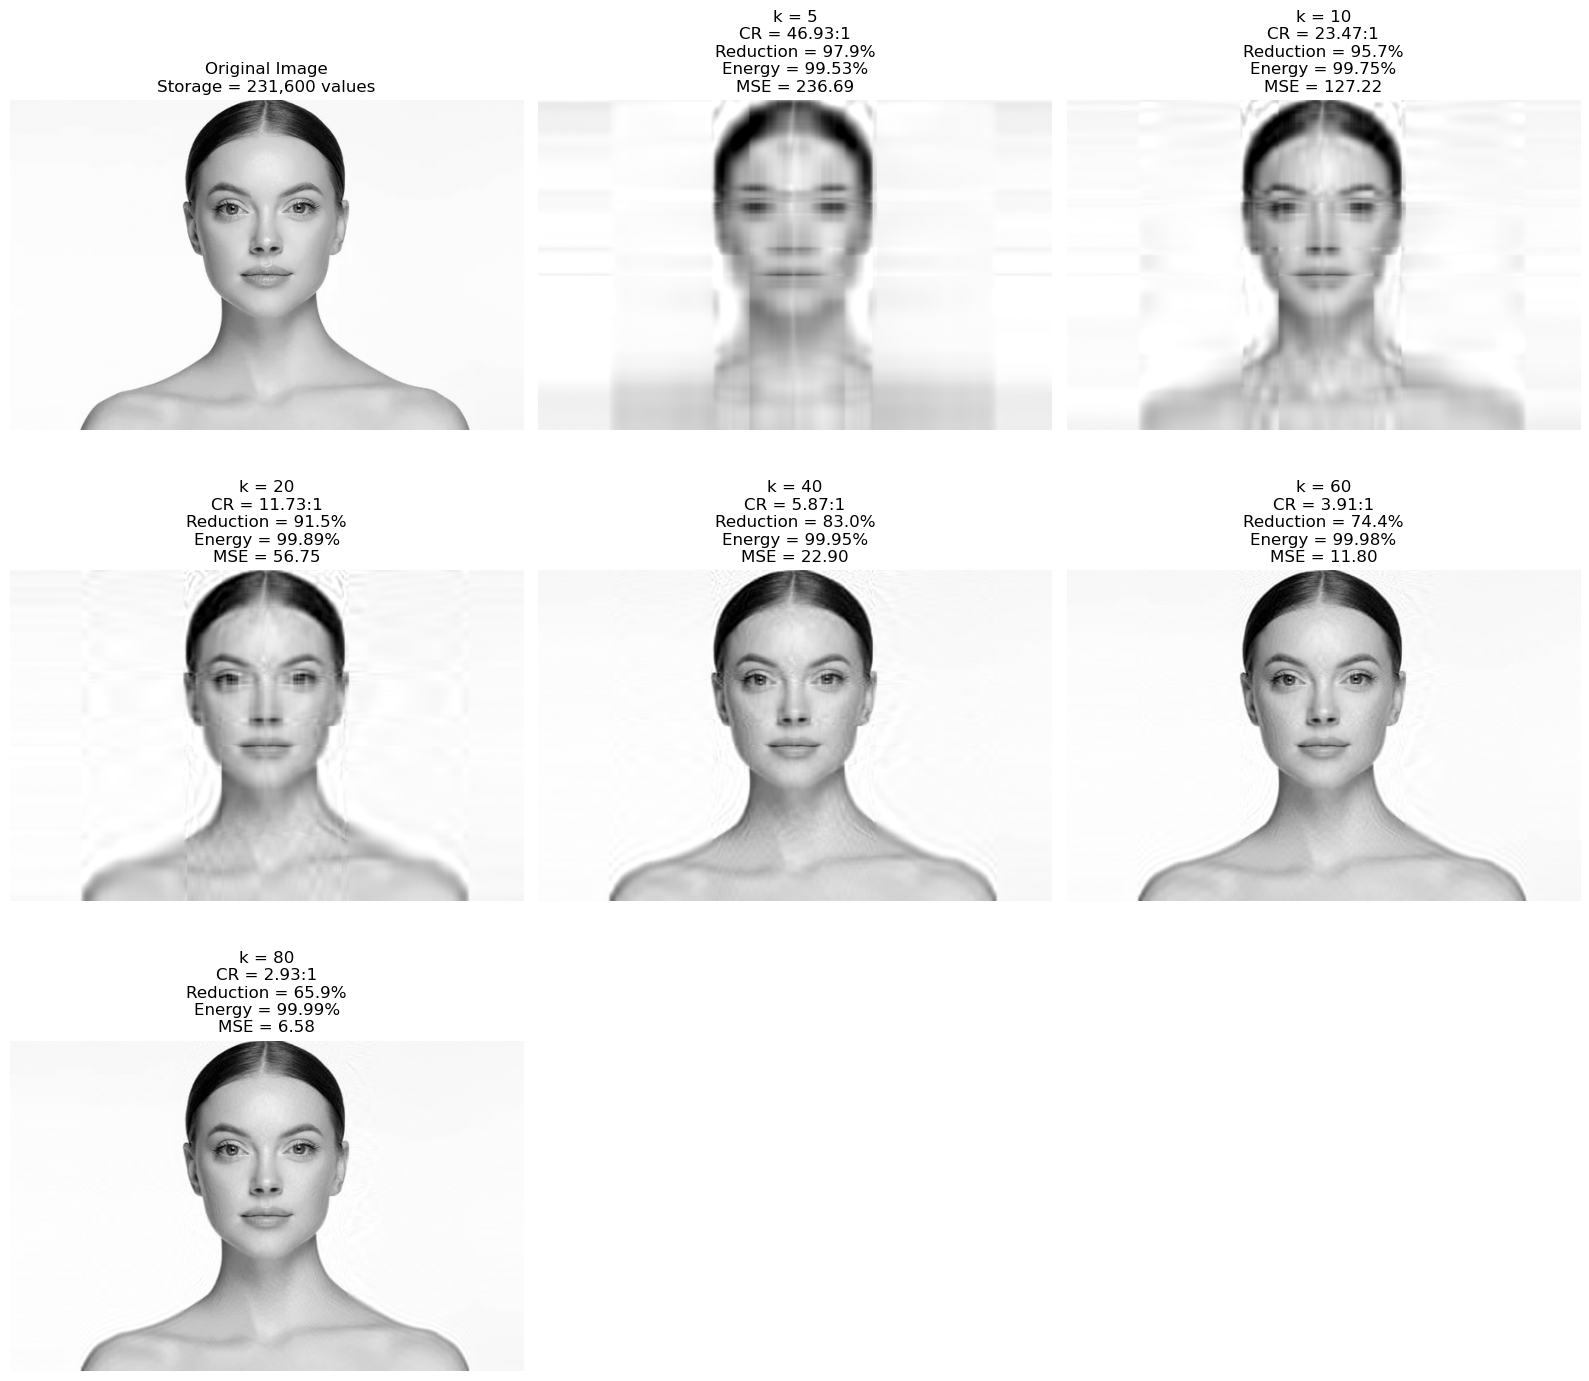

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import math

# =========================================================
# LOAD IMAGE
# =========================================================

img_path = "svd5.jfif"   # <-- change path

img = Image.open(img_path).convert("L")
A = np.array(img, dtype=float)

# =========================================================
# IMAGE SIZE INFORMATION
# =========================================================

rows, cols = A.shape

# Original storage
original_storage = A.size

# =========================================================
# SVD DECOMPOSITION
# =========================================================

U, S, VT = np.linalg.svd(A, full_matrices=False)

# =========================================================
# TOTAL IMAGE ENERGY
# =========================================================

total_energy = np.sum(S**2)

# =========================================================
# VALUES OF k TO COMPARE
# =========================================================

k_values = [5, 10, 20, 40, 60, 80]

# =========================================================
# PLOT SETTINGS
# =========================================================

n_plots = len(k_values) + 1

cols_plot = 3
rows_plot = math.ceil(n_plots / cols_plot)

plt.figure(figsize=(16, 5 * rows_plot))

# =========================================================
# ORIGINAL IMAGE
# =========================================================

plt.subplot(rows_plot, cols_plot, 1)

plt.imshow(A, cmap='gray')

plt.title(
    f"Original Image\n"
    f"Storage = {original_storage:,} values"
)

plt.axis("off")

# =========================================================
# RECONSTRUCTIONS
# =========================================================

for i, k in enumerate(k_values):

    # Reconstruction
    A_k = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

    A_k = np.clip(A_k, 0, 255)

    # Storage required for SVD representation
    compressed_storage = (
        U[:, :k].size +
        S[:k].size +
        VT[:k, :].size
    )

    # Compression Ratio
    compression_ratio = (
        original_storage /
        compressed_storage
    )

# =========================================================
# ENERGY RETAINED
# =========================================================

    retained_energy = np.sum(S[:k]**2)

    energy_retained_percentage = (
    retained_energy /
    total_energy
   ) * 100

    # Reduction Percentage
    reduction_percentage = (
        (original_storage - compressed_storage)
        / original_storage
    ) * 100

# =========================================================
# RECONSTRUCTION ERROR (MSE)
# =========================================================

    mse = np.mean((A - A_k)**2)

    # Plot image
    plt.subplot(rows_plot, cols_plot, i + 2)

    plt.imshow(A_k, cmap='gray')

    plt.title(
    f"k = {k}\n"
    f"CR = {compression_ratio:.2f}:1\n"
    f"Reduction = {reduction_percentage:.1f}%\n"
    f"Energy = {energy_retained_percentage:.2f}%\n"
    f"MSE = {mse:.2f}"
)

    plt.axis("off")

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "svd_comparison.png",
    dpi=300,
    bbox_inches="tight"
 )
plt.show()

Original Shape: (386, 600)
Padded Shape: (448, 640)
Number of patches: 70

First 9 patch locations:

Patch 1: (0, 0)
Patch 2: (0, 64)
Patch 3: (0, 128)
Patch 4: (0, 192)
Patch 5: (0, 256)
Patch 6: (0, 320)
Patch 7: (0, 384)
Patch 8: (0, 448)
Patch 9: (0, 512)


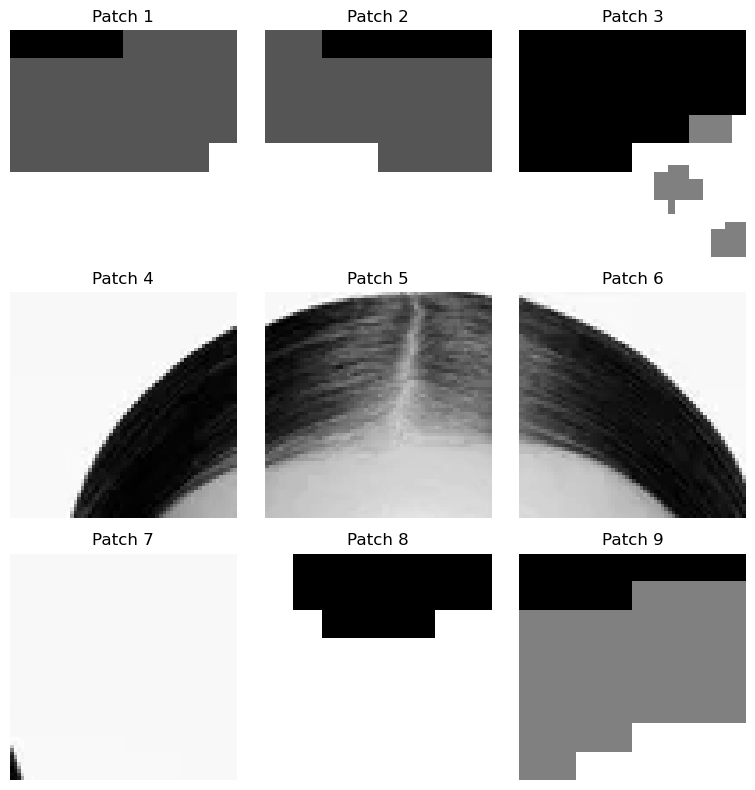

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =========================================================
# LOAD IMAGE
# =========================================================

img_path = "svd5.jfif"

img = Image.open(img_path).convert("L")

A_original = np.array(img)

print("Original Shape:", A_original.shape)

rows, cols = A_original.shape

pad_rows = (64 - rows % 64) % 64
pad_cols = (64 - cols % 64) % 64

A = np.pad(
    A_original,
    ((0, pad_rows), (0, pad_cols)),
    mode='edge'
)

print("Padded Shape:", A.shape)

# =========================================================
# PATCH SIZE
# =========================================================

patch_size = 64

# =========================================================
# EXTRACT PATCHES
# =========================================================

patches = []
patch_locations = []

rows, cols = A.shape

for i in range(0, rows - patch_size + 1, patch_size):
    for j in range(0, cols - patch_size + 1, patch_size):

        patch = A[
            i:i+patch_size,
            j:j+patch_size
        ]

        patches.append(patch)

        patch_locations.append((i, j))

print("Number of patches:", len(patches))

print("\nFirst 9 patch locations:\n")

for idx in range(min(9, len(patches))):
    print(
        f"Patch {idx+1}: {patch_locations[idx]}"
    )

# =========================================================
# DISPLAY FIRST 9 PATCHES
# =========================================================

plt.figure(figsize=(8,8))

for idx in range(min(9, len(patches))):

    plt.subplot(3,3,idx+1)

    plt.imshow(
        patches[idx],
        cmap='gray'
    )

    plt.title(f"Patch {idx+1}")

    plt.axis("off")

plt.tight_layout()
plt.tight_layout()

plt.savefig(
    "patch_grid.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
# =========================================================
# PATCH-WISE SVD COMPRESSION
# =========================================================

kp = 10

compressed_patches = []

# =========================================================
# ENERGY RETENTION VARIABLES
# =========================================================

total_original_energy = 0
total_retained_energy = 0

for patch in patches:

    patch = patch.astype(float)

    # SVD
    U, S, VT = np.linalg.svd(
        patch,
        full_matrices=False
    )
# Energy in this patch
    patch_total_energy = np.sum(S**2)

# Energy retained by first kp singular values
    patch_retained_energy = np.sum(S[:kp]**2)

# Accumulate
    total_original_energy += patch_total_energy
    total_retained_energy += patch_retained_energy
    
# Reconstruction
    patch_k = (
        U[:, :kp]
        @ np.diag(S[:kp])
        @ VT[:kp, :]
    )

    patch_k = np.clip(
        patch_k,
        0,
        255
    )

    compressed_patches.append(
        patch_k
    )

print("Patch compression completed.")
energy_retention = (
    total_retained_energy
    / total_original_energy
) * 100

print(
    f"Patch-wise Energy Retention = "
    f"{energy_retention:.4f}%"
)

Patch compression completed.
Patch-wise Energy Retention = 99.9773%


In [11]:
# =========================================================
# RECONSTRUCT IMAGE
# =========================================================

reconstructed = np.zeros_like(
    A,
    dtype=float
)

patch_index = 0

for i in range(
    0,
    rows - patch_size + 1,
    patch_size
):

    for j in range(
        0,
        cols - patch_size + 1,
        patch_size
    ):

        reconstructed[
            i:i+patch_size,
            j:j+patch_size
        ] = compressed_patches[
            patch_index
        ]

        patch_index += 1

print("Image reconstruction completed.")

Image reconstruction completed.



PATCH-WISE SVD RESULTS
----------------------
Original Storage = 286720
Compressed Storage = 90300
Compression Ratio = 3.18
Storage Reduction = 68.51%

MSE = 11.4288
Valid Region MSE = 11.4288
Image saved as patchwise_svd_k10.png


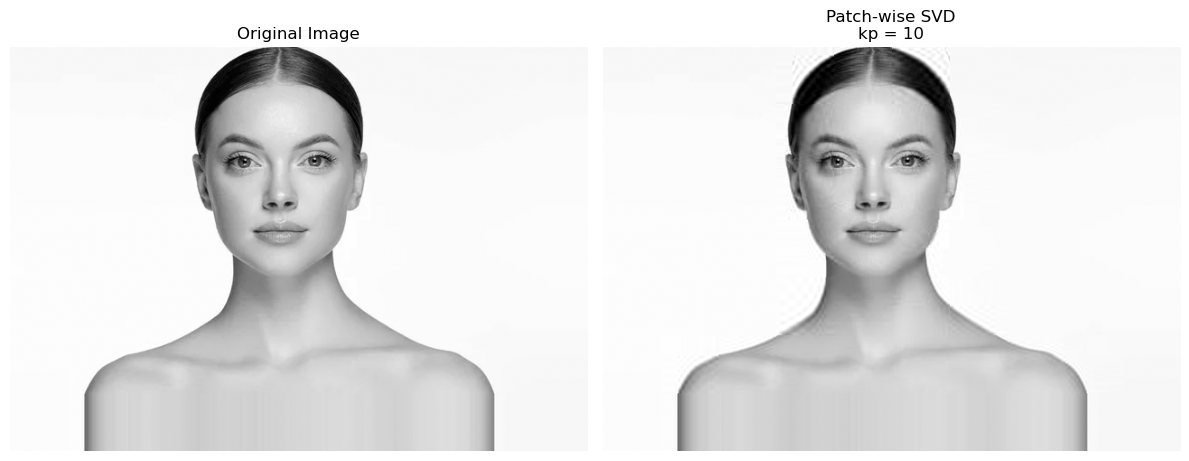

In [15]:
# =========================================================
# PATCH-WISE COMPRESSION RATIO
# =========================================================

# Original storage
original_storage = rows * cols

# Number of patches
num_patches = len(patches)

# Storage needed per patch
# Uk : 64 x kp
# Sk : kp
# VTk : kp x 64

storage_per_patch = (
    patch_size * kp
    + kp
    + kp * patch_size
)

# Total compressed storage
compressed_storage = (
    num_patches
    * storage_per_patch
)

# Compression ratio
compression_ratio = (
    original_storage
    / compressed_storage
)

# Storage reduction %
storage_reduction = (
    (original_storage
     - compressed_storage)
    / original_storage
) * 100

print("\nPATCH-WISE SVD RESULTS")
print("----------------------")
print(
    f"Original Storage = "
    f"{original_storage}"
)

print(
    f"Compressed Storage = "
    f"{compressed_storage}"
)

print(
    f"Compression Ratio = "
    f"{compression_ratio:.2f}"
)

print(
    f"Storage Reduction = "
    f"{storage_reduction:.2f}%"
)
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)

plt.imshow(
    A,
    cmap='gray'
)

plt.title("Original Image")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(
    reconstructed,
    cmap='gray'
)

plt.title(
    f"Patch-wise SVD\n"
    f"kp = {kp}"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "patchwise_svd_k10.png",
    dpi=300,
    bbox_inches="tight"
)

# =========================================================
# MEAN SQUARED ERROR
# =========================================================

mse = np.mean(
   (A.astype(float) - reconstructed)**2
)

print(f"\nMSE = {mse:.4f}")

covered_rows = (rows // patch_size) * patch_size
covered_cols = (cols // patch_size) * patch_size

valid_original = A[:covered_rows, :covered_cols]

valid_reconstructed = reconstructed[
    :covered_rows,
    :covered_cols
]

mse_valid = np.mean(
   (valid_original.astype(float)
   - valid_reconstructed)**2
)

print(f"Valid Region MSE = {mse_valid:.4f}")

# =========================================================
# SAVE RECONSTRUCTED IMAGE
# =========================================================

from PIL import Image

reconstructed_uint8 = reconstructed.astype(np.uint8)

Image.fromarray(
    reconstructed_uint8
).save(
    "patchwise_svd_k10.png"
)

print(
    "Image saved as patchwise_svd_k10.png"
)
plt.tight_layout()

plt.savefig(
    "patchwise_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()